In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Ice_cream selling data.csv")

In [3]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


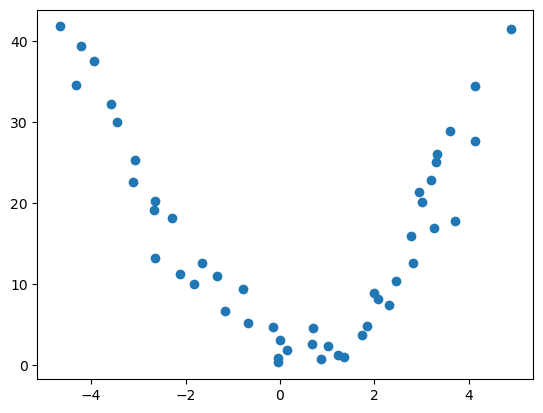

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

In [7]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


* Feature column has very weak relation with taget column so the model performance will not be good

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
model.intercept_

np.float64(17.139213127718417)

In [14]:
model.coef_

array([-1.14658686])

In [16]:
ytrain_pred=model.predict(x_train)

In [17]:
ytest_pred=model.predict(x_test)

In [19]:
error=y_train-ytrain_pred
error

12    -8.342361
4     11.042195
34    -7.068653
8     -0.976452
3     15.872002
6      1.932092
40     9.382303
41     3.593455
46    22.127929
15    -7.702291
9      0.099389
16   -11.795178
24   -13.772684
33    -6.589195
30   -11.361582
0     19.358084
43    12.790464
32    -5.903007
5      8.899652
29   -14.626954
11    -1.638915
36     2.050464
1     12.572596
21   -16.280474
2     17.412088
37    -1.324117
35    -3.968282
23   -15.036675
39     6.438895
10    -6.903557
22   -13.963744
18   -12.701567
48    29.992774
20   -16.852044
7      4.692827
42    11.805034
14    -6.427765
28   -14.424269
38     7.597522
Name: Ice Cream Sales (units), dtype: float64

In [20]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error

In [21]:
r2_score(y_train,ytrain_pred)*100

6.579063815950037

In [22]:
r2_score(y_test,ytest_pred)*100

-57.51270190188227

In [23]:
mean_absolute_error(y_train,ytrain_pred)

10.136398159361041

In [24]:
mean_absolute_error(y_test,ytest_pred)

11.752026695440602

In [25]:
mean_squared_error(y_train,ytrain_pred)

143.33160093981343

In [26]:
mean_squared_error(y_test,ytest_pred)

149.32629119325185

In [27]:
root_mean_squared_error(y_train,ytrain_pred)

11.972117646423854

In [29]:
root_mean_squared_error(y_test,ytest_pred)

12.219913714640208

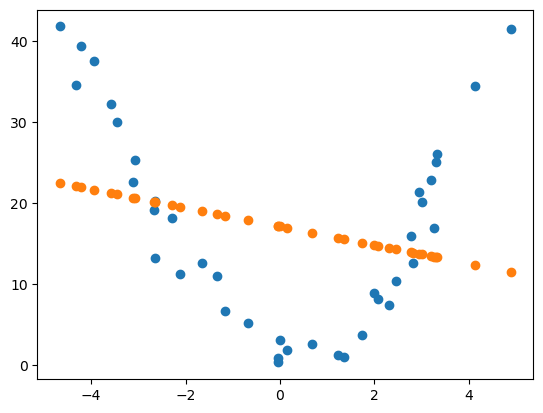

In [31]:
plt.scatter(x_train,y_train)
plt.scatter(x_train,ytrain_pred)

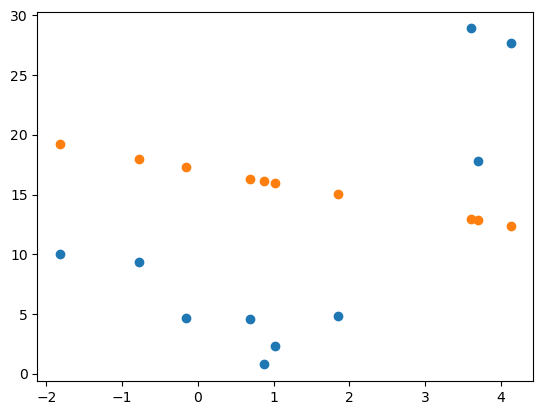

In [32]:
plt.scatter(x_test,y_test)
plt.scatter(x_test,ytest_pred)

* Used Linear Regression on Non-Linear data which is wrong

# Correct Procedure for Non-linear data

In [33]:
from sklearn.preprocessing import PolynomialFeatures

In [34]:
poly=PolynomialFeatures(degree=2)

In [35]:
updated_xtrain=poly.fit_transform(x_train)
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [36]:
updated_xtest=poly.transform(x_test)
updated_xtest

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [37]:
model=LinearRegression()
model.fit(updated_xtrain,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
ypred_train=model.predict(updated_xtrain)

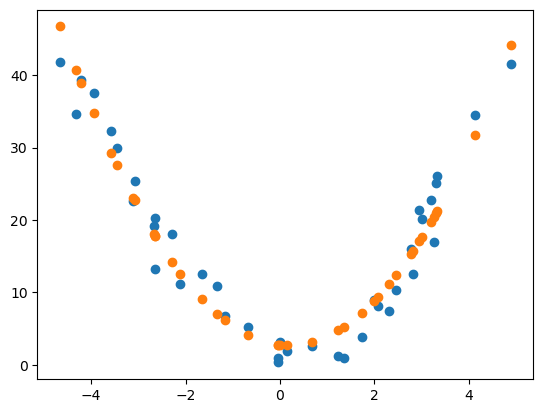

In [39]:
plt.scatter(updated_xtrain[:,1],y_train)
plt.scatter(updated_xtrain[:,1],ypred_train)

In [40]:
pred_ytest=model.predict(updated_xtest)

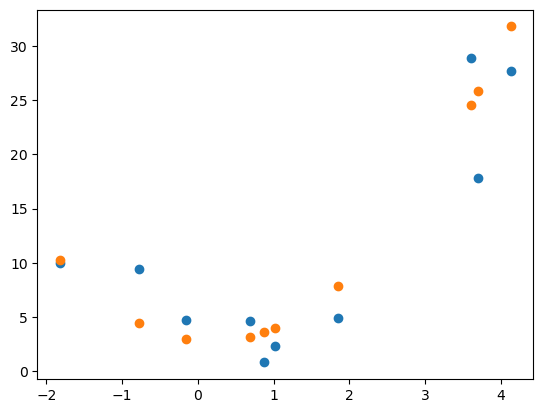

In [41]:
plt.scatter(updated_xtest[:,1],y_test)
plt.scatter(updated_xtest[:,1],pred_ytest)

In [42]:
r2_score(y_train,ypred_train)*100

94.13665676490518

In [44]:
r2_score(y_test,pred_ytest)*100

84.30551371938843

In [45]:
mean_absolute_error(y_train,ytrain_pred)

10.136398159361041

In [46]:
mean_absolute_error(y_test,pred_ytest)

3.2299819836597266

In [47]:
mean_squared_error(y_train,ypred_train)

8.995867597495232

In [48]:
mean_squared_error(y_test,pred_ytest)

14.878796440981466

In [49]:
root_mean_squared_error(y_train,ytrain_pred)

11.972117646423854

In [50]:
root_mean_squared_error(y_test,pred_ytest)

3.8573042971719858

# degree=2    (best degree) compared to other degree
* r2_score train = 0.9413665676490518
* r2_score test = 0.843055137193884           
* both MAE(10.136398159361041) and RMSE(11.972117646423854) are nearly equal in train data
* test data MAE(3.2299819836597274) and RMSE(3.857304297171988)

# degree = 3
* r2_score train = 0.9469116778215552
* r2_score test= 0.8405107685716915
* Train MAE(10.136398159361041) and RMSE(11.972117646423854)
* Test MAE(3.228121129776889) and RMSE(3.888445634341502)

# degree = 4
* r2_score train = 0.9590068634754769
* r2_score test = 0.8054468908427623
* Train MAE(10.136398159361041) and RMSE(11.972117646423854)

# degree = 5
* r2_score train = 0.9625276778765787
* r2_score test = 0.7781622233034887
* Train MAE(10.136398159361041) and RMSE(11.972117646423854)
* Test MAE(3.5107931284659424) and RMSE(4.585937173892854)